<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1285 | Val: 362 | Test: 203


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 4, accumulation steps = 4 (effective batch size ≈ 16, tuned value = 14)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 4 micro-batches per optimizer step (effective batch size ≈ micro_batch x 4).
[DenseNet-121] Epoch   1/100 | LR: 2.74e-04 | train loss 1.2461 acc 0.459 | val loss 0.9112 acc 0.602 *
[DenseNet-121] Epoch   2/100 | LR: 2.74e-04 | train loss 1.0482 acc 0.557 | val loss 1.0299 acc 0.544
[DenseNet-121] Epoch   3/100 | LR: 2.74e-04 | train loss 0.9625 acc 0.612 | val loss 0.8915 acc 0.688 *
[DenseNet-121] Epoch   4/100 | LR: 2.74e-04 | train loss 0.9570 acc 0.610 | val loss 0.7470 acc 0.660 *
[DenseNet-121] Epoch   5/100 | LR: 2.74e-04 | train loss 0.9030 acc 0.628 | val loss 0.7617 acc 0.688
[DenseNet-121] Epoch   6/100 | LR: 2.74e-04 | train loss 0.8818 acc 0.635 | val loss 0.6571 acc 0.762 *
[DenseNet-121] Epoch   7/100 | LR: 2.74e-05 | train loss 0.8331 acc 0.654 | val loss 0.7222 acc 0.707
[DenseNet-121] Epoch   8/100 | LR: 2.74e-05 | train loss 0.7585 acc 0.703 | val loss 0.5912 acc 0.765 *
[DenseNet-121] Epoch   9/100 | LR: 2.74e-05 | train l

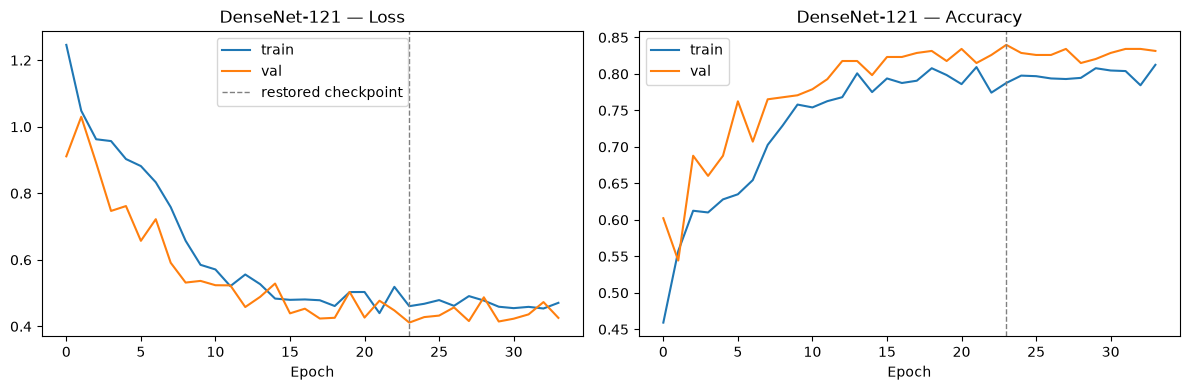

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.828


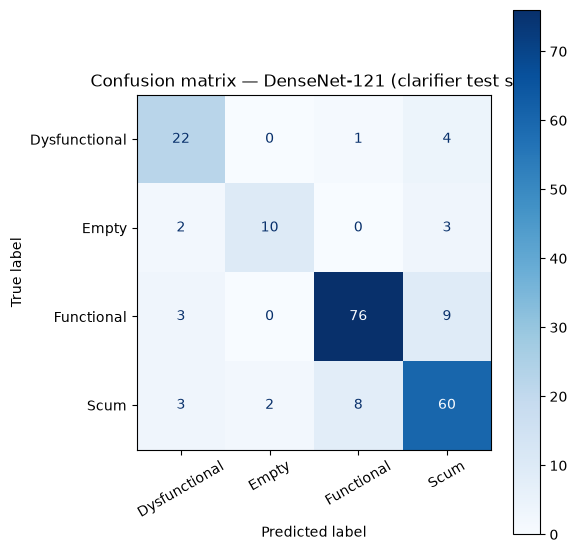

               precision    recall  f1-score   support

Dysfunctional      0.733     0.815     0.772        27
        Empty      0.833     0.667     0.741        15
   Functional      0.894     0.864     0.879        88
         Scum      0.789     0.822     0.805        73

     accuracy                          0.828       203
    macro avg      0.813     0.792     0.799       203
 weighted avg      0.831     0.828     0.828       203



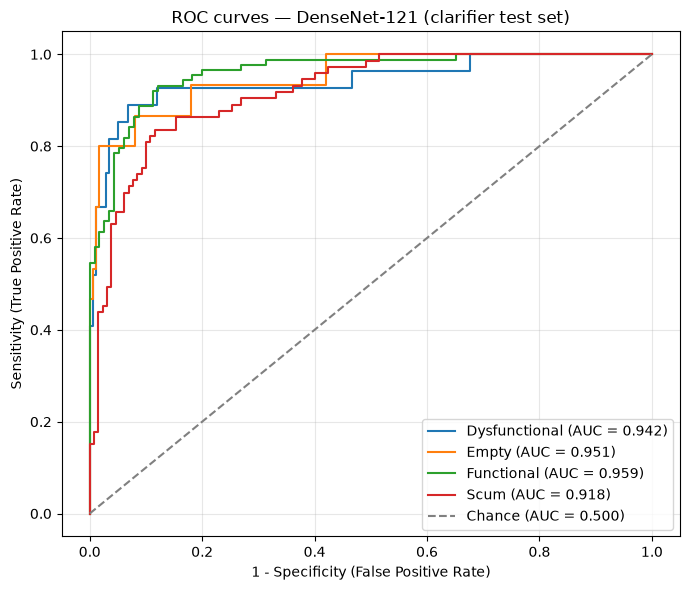

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.942
  Empty          : 0.951
  Functional     : 0.959
  Scum           : 0.918

Mean AUC: 0.943


(np.float64(0.8275862068965517),
 {'Dysfunctional': 0.9419191919191919,
  'Empty': 0.950709219858156,
  'Functional': 0.9594861660079052,
  'Scum': 0.917913593256059})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/results_densenet121.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
